In [1]:
!pip install -q open_clip_torch pymilvus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.3/248.3 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.3/55.3 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 107.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
import os
import open_clip
import glob
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
from pymilvus import MilvusClient


In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, _, preprocess = open_clip.create_model_and_transforms('ViT-H-14-quickgelu', pretrained='dfn5b')
model.eval()
tokenizer = open_clip.get_tokenizer('ViT-H-14-quickgelu')

open_clip_pytorch_model.bin:   0%|          | 0.00/3.94G [00:00<?, ?B/s]

In [5]:
keyframes_dir = '/root/.cache/kagglehub/datasets/khitrnhxun/aic-keyframesb1-reduced/versions/2/Keyframes'
all_keyframe_paths = dict()
for part in sorted(os.listdir(keyframes_dir)):
    data_part = part.split('_')[-1] # L01, L02 for ex
    all_keyframe_paths[data_part] =  dict()

for data_part in sorted(all_keyframe_paths.keys()):
    data_part_path = f'{keyframes_dir}/{data_part}'
    video_dirs = sorted(os.listdir(data_part_path))
    video_ids = [video_dir.split('_')[-1] for video_dir in video_dirs]
    for video_id, video_dir in zip(video_ids, video_dirs):
        keyframe_paths = sorted(glob.glob(f'{data_part_path}/{video_dir}/*.webp'))
        all_keyframe_paths[data_part][video_id] = keyframe_paths

In [13]:
bs = 4
save_dir = './metaclip_features'
if not os.path.exists(save_dir):
  os.mkdir(save_dir)
model = model.to(device)

for key, video_keyframe_paths in tqdm(all_keyframe_paths.items()):
    video_ids = sorted(video_keyframe_paths.keys())

    if not os.path.exists(os.path.join(save_dir, key)):
        os.mkdir(os.path.join(save_dir, key))

    for video_id in tqdm(video_ids):
        video_feats = []
        video_keyframe_path = video_keyframe_paths[video_id]
        for i in range(0, len(video_keyframe_path), bs):
            # Support batchsize inferencing
            images = []
            image_paths = video_keyframe_path[i:i+bs]
            for image_path in image_paths:
                image = preprocess(Image.open(image_path)).unsqueeze(0)
                images.append(image)
            images = torch.cat(images).to(device)

            with torch.no_grad():
                image_feats = model.encode_image(images)
            image_feats /= image_feats.norm(dim=-1, keepdim=True)

            for b in range(image_feats.shape[0]):
                video_feats.append(image_feats[b].detach().cpu().numpy().astype(np.float32).flatten())

        np.save(f'{save_dir}/{key}/{video_id}.npy', video_feats)

 50%|█████     | 5/10 [1:34:43<1:34:43, 1136.62s/it]


KeyboardInterrupt: 

In [21]:
feature_shape = 1024
features_dir = './metaclip_features'
client = MilvusClient("./im_vec_milvus.db")

client.create_collection(
    collection_name="quickgeluclip",
    dimension=feature_shape
)

global_id = 0

for data_part in tqdm(sorted(os.listdir(features_dir))):
    part_dir = os.path.join(features_dir, data_part)
    for feature_path in tqdm(sorted(glob.glob(os.path.join(part_dir, '*.npy')))):
        feats = np.load(feature_path)  # [num_frames, 768]
        video_id = os.path.splitext(os.path.basename(feature_path))[0]

        data = []
        for i, feat in enumerate(feats):
          data.append({
              "id": global_id,
              "vector": feat.astype(np.float32),
              "video_id": video_id,
              "frame_index": i,
              "split": data_part,
          })
          global_id += 1

        client.insert(
            collection_name="quickgeluclip",
            data=data
        )


  0%|          | 0/6 [00:00<?, ?it/s]
0it [00:00, ?it/s]

  3%|▎         | 1/31 [00:00<00:04,  6.19it/s]

(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)



 13%|█▎        | 4/31 [00:00<00:03,  8.94it/s]

(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)



 19%|█▉        | 6/31 [00:00<00:02,  9.27it/s]

...


 89%|████████▉ | 25/28 [00:03<00:00,  8.39it/s]

(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)



 96%|█████████▋| 27/28 [00:03<00:00,  8.64it/s]

(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)



100%|██████████| 6/6 [00:19<00:00,  3.30s/it]


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("khitrnhxun/aic-keyframesb1-reduced")

print("Path to dataset files:", path)

100%|██████████| 1.16G/1.16G [02:14<00:00, 9.22MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/khitrnhxun/aic-keyframesb1-reduced/versions/2


In [ ]:
ls /root/.cache/kagglehub/datasets/khitrnhxun/aic-keyframesb1-reduced/versions/2/Keyframes/L01/V001

0001.webp  0035.webp  0069.webp  0103.webp  0137.webp  0171.webp  0205.webp
0002.webp  0036.webp  0070.webp  0104.webp  0138.webp  0172.webp  0206.webp
0003.webp  0037.webp  0071.webp  0105.webp  0139.webp  0173.webp  0207.webp
0004.webp  0038.webp  0072.webp  0106.webp  0140.webp  0174.webp  0208.webp
0005.webp  0039.webp  0073.webp  0107.webp  0141.webp  0175.webp  0209.webp
0006.webp  0040.webp  0074.webp  0108.webp  0142.webp  0176.webp  0210.webp
0007.webp  0041.webp  0075.webp  0109.webp  0143.webp  0177.webp  0211.webp
0008.webp  0042.webp  0076.webp  0110.webp  0144.webp  0178.webp  0212.webp
0009.webp  0043.webp  0077.webp  0111.webp  0145.webp  0179.webp  0213.webp
0010.webp  0044.webp  0078.webp  0112.webp  0146.webp  0180.webp  0214.webp
0011.webp  0045.webp  0079.webp  0113.webp  0147.webp  0181.webp  0215.webp
0012.webp  0046.webp  0080.webp  0114.webp  0148.webp  0182.webp  0216.webp
0013.webp  0047.webp  0081.webp  0115.webp  0149.webp  0183.webp  0217.webp
0014.webp  0

In [11]:
import open_clip
open_clip.list_pretrained()

[('RN50', 'openai'),
 ('RN50', 'yfcc15m'),
 ('RN50', 'cc12m'),
 ('RN101', 'openai'),
 ('RN101', 'yfcc15m'),
 ('RN50x4', 'openai'),
 ('RN50x16', 'openai'),
 ('RN50x64', 'openai'),
 ('ViT-B-32', 'openai'),
 ('ViT-B-32', 'laion400m_e31'),
 ('ViT-B-32', 'laion400m_e32'),
 ('ViT-B-32', 'laion2b_e16'),
 ('ViT-B-32', 'laion2b_s34b_b79k'),
 ('ViT-B-32', 'datacomp_xl_s13b_b90k'),
 ('ViT-B-32', 'datacomp_m_s128m_b4k'),
 ('ViT-B-32', 'commonpool_m_clip_s128m_b4k'),
 ('ViT-B-32', 'commonpool_m_laion_s128m_b4k'),
 ('ViT-B-32', 'commonpool_m_image_s128m_b4k'),
 ('ViT-B-32', 'commonpool_m_text_s128m_b4k'),
 ('ViT-B-32', 'commonpool_m_basic_s128m_b4k'),
 ('ViT-B-32', 'commonpool_m_s128m_b4k'),
 ('ViT-B-32', 'datacomp_s_s13m_b4k'),
 ('ViT-B-32', 'commonpool_s_clip_s13m_b4k'),
 ('ViT-B-32', 'commonpool_s_laion_s13m_b4k'),
 ('ViT-B-32', 'commonpool_s_image_s13m_b4k'),
 ('ViT-B-32', 'commonpool_s_text_s13m_b4k'),
 ('ViT-B-32', 'commonpool_s_basic_s13m_b4k'),
 ('ViT-B-32', 'commonpool_s_s13m_b4k'),
 ('ViT-

In [15]:
import json
from tqdm import tqdm

index2imgpath = {}
current_index = 0  # FAISS index global offset

for key, video_keyframe_paths in tqdm(all_keyframe_paths.items()):
    for video_id in sorted(video_keyframe_paths.keys()):
        image_paths = video_keyframe_paths[video_id]
        for img_path in image_paths:
            index2imgpath[str(current_index)] = img_path
            current_index += 1

# Lưu lại file ánh xạ
with open("index2imgpath.json", "w") as f:
    json.dump(index2imgpath, f, indent=2)


100%|██████████| 10/10 [00:00<00:00, 221.56it/s]


🔍 Query: A man is sleeping


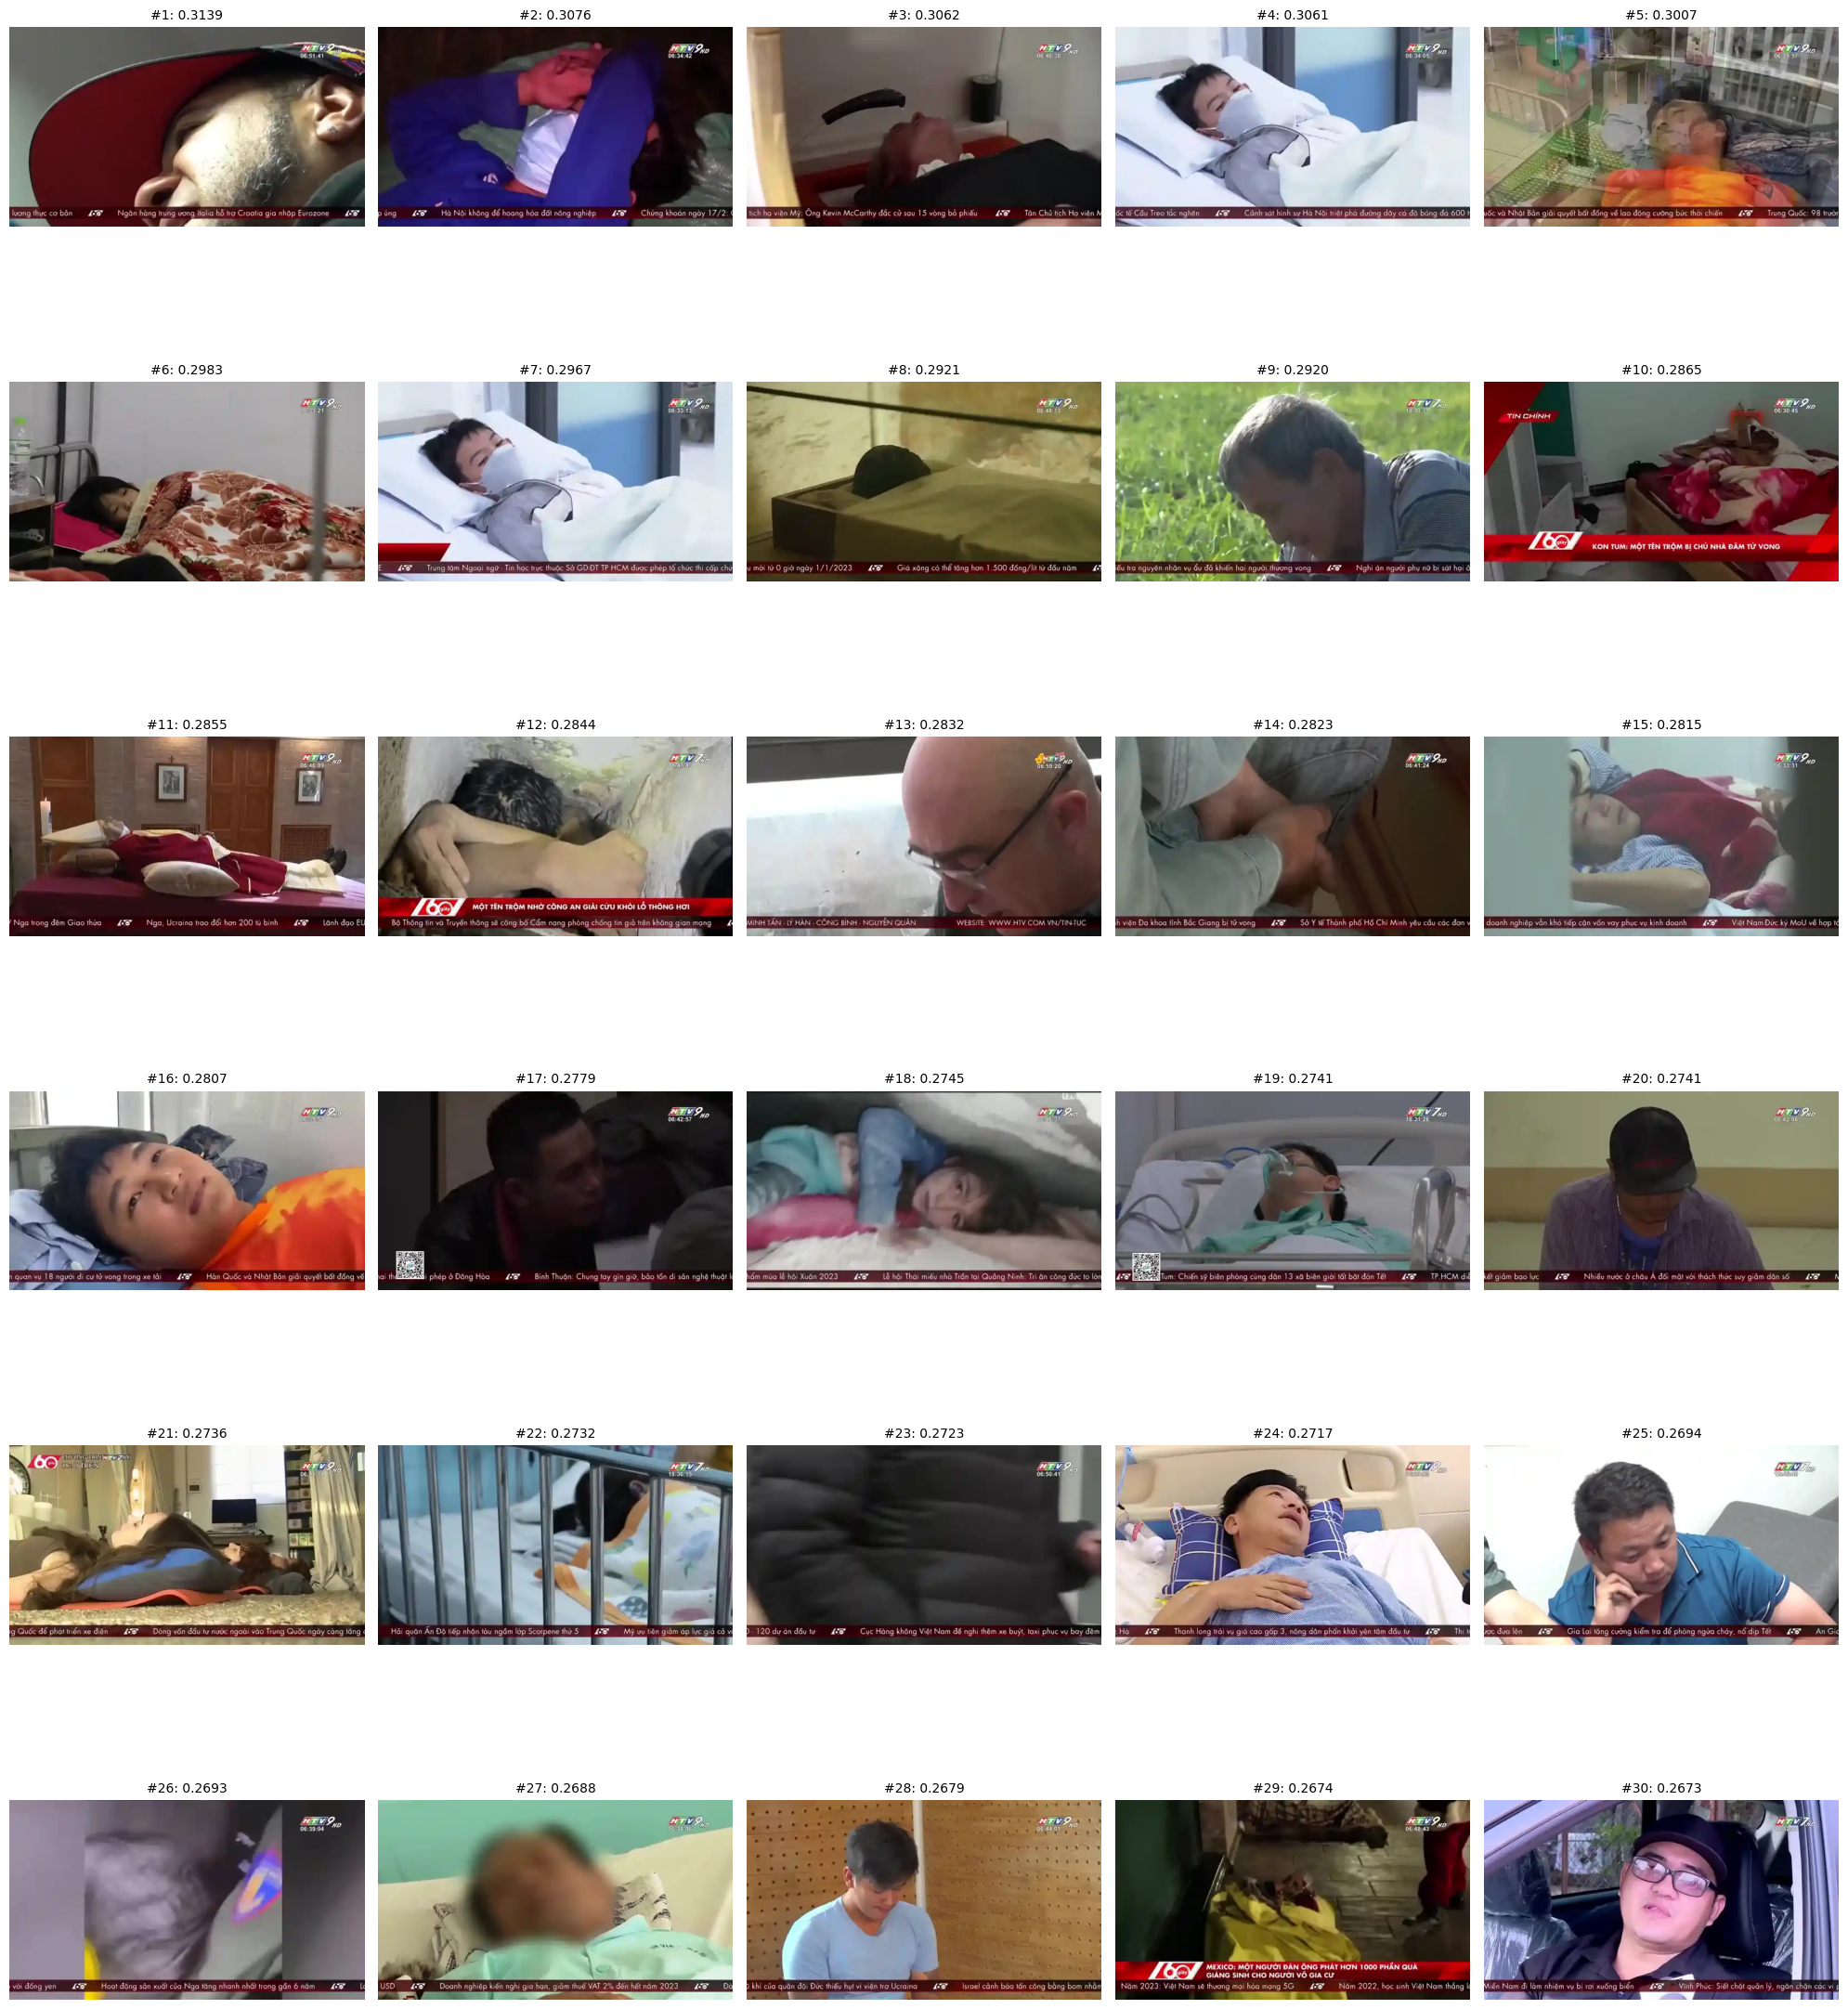

In [34]:
import matplotlib.pyplot as plt

with open("index2imgpath.json", "r") as f:
    index2imgpath = json.load(f)

# --- Encode text query ---
text_query = "A man is sleeping"

with torch.no_grad():
    text_tokens = tokenizer([text_query]).to(device)
    text_feat = model.encode_text(text_tokens)
    text_feat /= text_feat.norm(dim=-1, keepdim=True)
    text_embedding = text_feat.cpu().numpy().astype("float32")

# --- Milvus search top 30 ---
search_result = client.search(
    collection_name="quickgeluclip",
    data=text_embedding.tolist(),
    limit=30
)

# --- Plot results ---
def show_top_images(results, index2imgpath, ncols=5):
    n = len(results)
    nrows = (n + ncols - 1) // ncols
    plt.figure(figsize=(ncols * 4, nrows * 4))

    for i, hit in enumerate(results):
        img_id = str(hit.id)
        img_path = index2imgpath.get(img_id)
        if not os.path.exists(img_path):
            continue
        try:
            img = Image.open(img_path).convert("RGB")
        except:
            continue

        plt.subplot(nrows, ncols, i + 1)
        plt.imshow(img)
        plt.title(f"#{i+1}: {hit.score:.4f}", fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# --- Run & Show ---
print(f"🔍 Query: {text_query}")
show_top_images(search_result[0], index2imgpath, ncols=5)
